In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [ ]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
import xarray as xr

from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
from models.model import CNN_Model, CNN_Model_ChannelAttention, CNN_Model_SpatialAttention
import pandas as pd
from torch import nn
from lightning.pytorch import loggers, seed_everything
from models.lightning import LitCNN_regression, AttributableTrainer
# from models.losses import get_loss
import matplotlib
from models.data import get_input_data_from_wandb_logger,get_input_data_from_wandb_logger_three_types
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
# matplotlib.use('tkagg')
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
import seaborn as sns 
import argparse
from tqdm.notebook import tqdm
import cartopy.crs as ccrs

Running imports...


In [ ]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

train_loader, val_loader, test_loader, ds_test = get_input_data_from_wandb_logger_three_types(wandb_logger)

callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,)

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_timesteps_predicted']*3
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variables'])


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready:
    Image size: 4096 (128x32)
    Input data: u850, v850, w850
    4 Predicted timesteps for future rainfall
    90th percentile predicted


In [ ]:

class CNN_Model_(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=3,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.conv_layer1 = nn.Sequential(
                                nn.Conv2d(input_channels, 
                                          out_channels_conv1, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, stride=1, padding=(size_conv_kernel-1)//2),
                                nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2, stride=2))
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        self.linear_size = image_size * self.output_cnn_channels // max_pools 
        self.fc = nn.Linear(self.linear_size, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc(cnn_out)  # Shape: (batch_size, output_size)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        


In [ ]:
NN = CNN_Model_(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 

class MultiCrossEntropyLoss(nn.Module):
    def __init__(self, timesteps):
        super(MultiCrossEntropyLoss, self).__init__()
        self.nll = torch.nn.NLLLoss(weight = torch.Tensor([1,1,5]))
        self.timesteps = timesteps
        
    def forward(self, pred, target):
        """
        Computes the loss for the given prediction.
        """
        loss = []
        pred = pred.view(-1, self.timesteps, 3)
        proba = torch.softmax(pred, dim=2)
        for timestep in range(self.timesteps):
            res = self.nll(torch.log(proba[:,timestep]), target[:,timestep])
            loss.append(res)
        loss = torch.mean(torch.stack(loss))
        return loss
    

loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)


In [ ]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_Model_            | 317 K  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
317 K     Trainable params
0         Non-trainable params
317 K     Total params
1.268     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=test_loader)

wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

In [ ]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3)#.cpu().numpy()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))

# model.test_true_values

# pred = torch.stack([corn_label_from_logits(y_scores[:,k]) for k in range(y_scores.shape[1])])

(array([ 6452.,     0.,     0.,     0.,     0., 12417.,     0.,     0.,
            0.,  1611.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

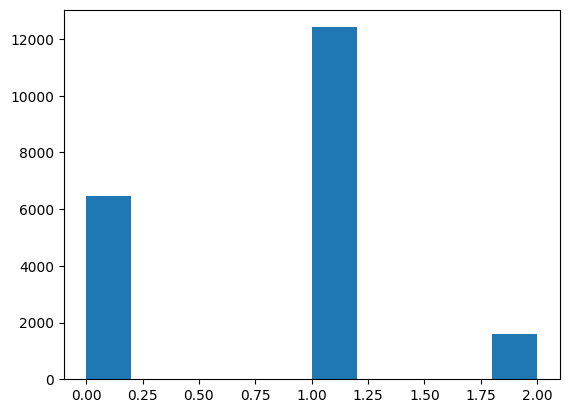

In [ ]:
targets.plot.hist()
# preds.plot.hist()

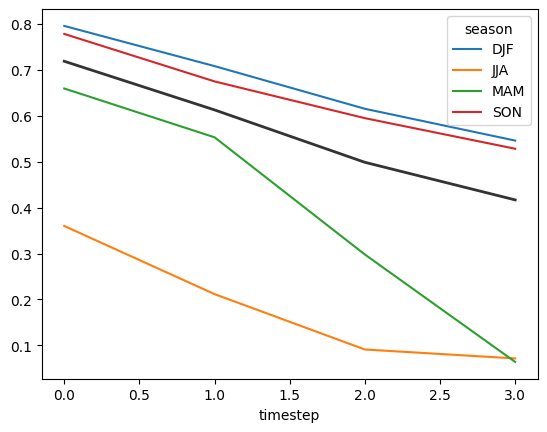

In [ ]:
TP = ((preds==targets)&(preds==2)).sum('time')
prec = TP/(preds==2).sum('time')
recall = TP/(targets==2).sum('time')
f1 = (2*prec*recall)/(prec+recall)

TP_season = ((preds==targets)&(preds==2)).groupby('time.season').sum()
prec_season = (TP_season/(preds==2).groupby('time.season').sum()).fillna(0)
recall_season = (TP_season/(targets==2).groupby('time.season').sum()).fillna(0)
f1_season = ((2*prec_season*recall_season)/(prec_season+recall_season)).fillna(0)

recall_season.plot(hue='season')
recall.plot(color='.2', lw=2)

In [ ]:
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

In [ ]:
times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')

num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2
pred_failed = num_extremes.loc[num_extremes_pred==0].sort_values().index

start_times_failed = pred_failed - pd.Timedelta(steps-1,'D')
# events

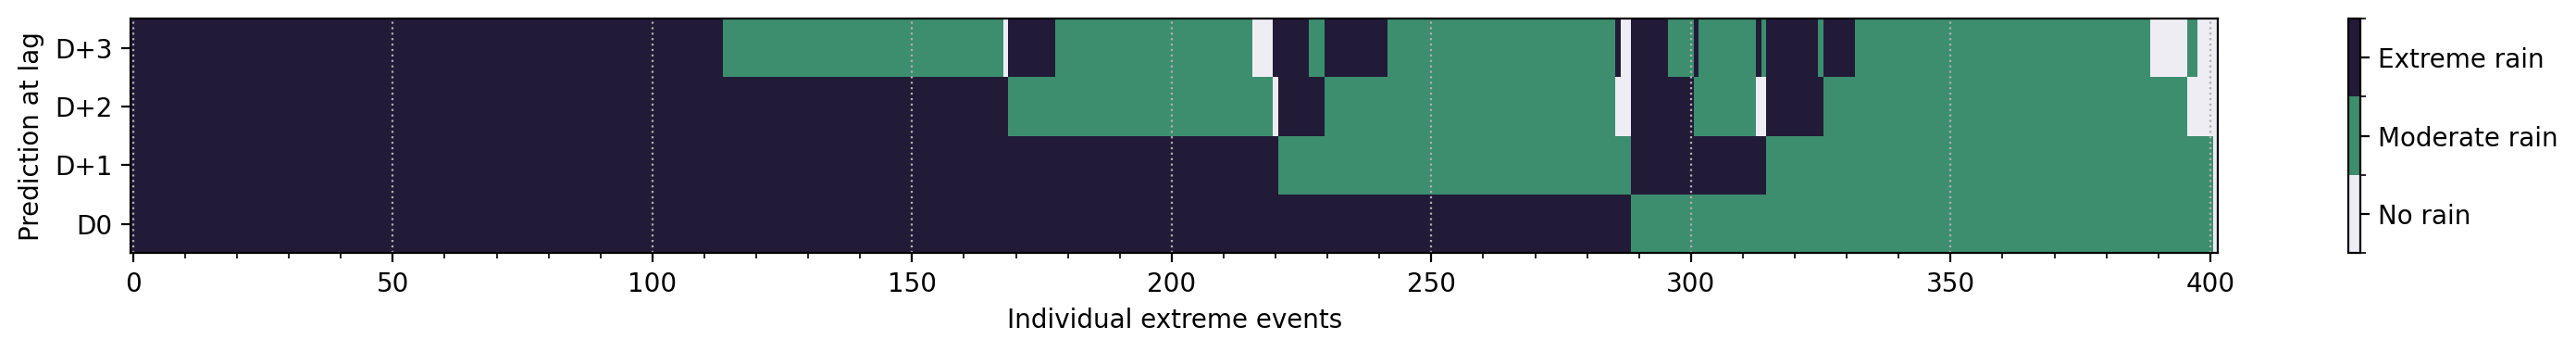

In [15]:
fig,ax = plt.subplots(figsize=(15,2), dpi=200)

df__ = df_.query("targets==2").pivot_table(index='pred_time', columns = 'timestep', values='pred').dropna()
df__ = df__.sort_values([3,2,1,0], ascending=True)
# df__['pred'] = 
df_hm = df__.astype(int).loc[df__.where(df__==2).count(axis=1).sort_values().index].T
df_hm = df_hm.T.sort_values([0,1,2,3], ascending=False).T

df_hm.index = ['D0','D+1','D+2','D+3']
df_hm = df_hm.loc[::-1]

# sns.heatmap(df_hm, cmap=cmo.rain)
colormesh = xr.DataArray(df_hm.values[::-1]).plot(cmap=cmo.rain, levels=[0,1,2,3])
colormesh.colorbar.ax.set_yticks([.5,1.5,2.5])
colormesh.colorbar.ax.set_yticklabels(['No rain','Moderate rain','Extreme rain'])
# colormesh.colorbar.ax.set_yticks([], which='minor')
# mesh = plt.pcolormesh(df_hm, cmap=cmo.rain, levels=[0,1,2])

# ax.set_xticklabels([])
ax.xaxis.set_minor_locator(plt.MultipleLocator(10))
ax.xaxis.set_major_locator(plt.MultipleLocator(50))
ax.grid(axis='x', ls=':')
ax.set_yticks([0,1,2,3])

ax.set_yticklabels(['D0','D+1','D+2','D+3'])
ax.set_xlabel('Individual extreme events')
ax.set_ylabel('Prediction at lag')
plt.tight_layout()



In [83]:
df_hm = times.groupby(times.index.month).apply(lambda df:df.value_counts()).unstack()
df_hm.columns
# [f'Detected at {k} times' for k in range(1,5)]

Index([1, 2, 3, 4], dtype='int64')

<Axes: xlabel='pred_time'>

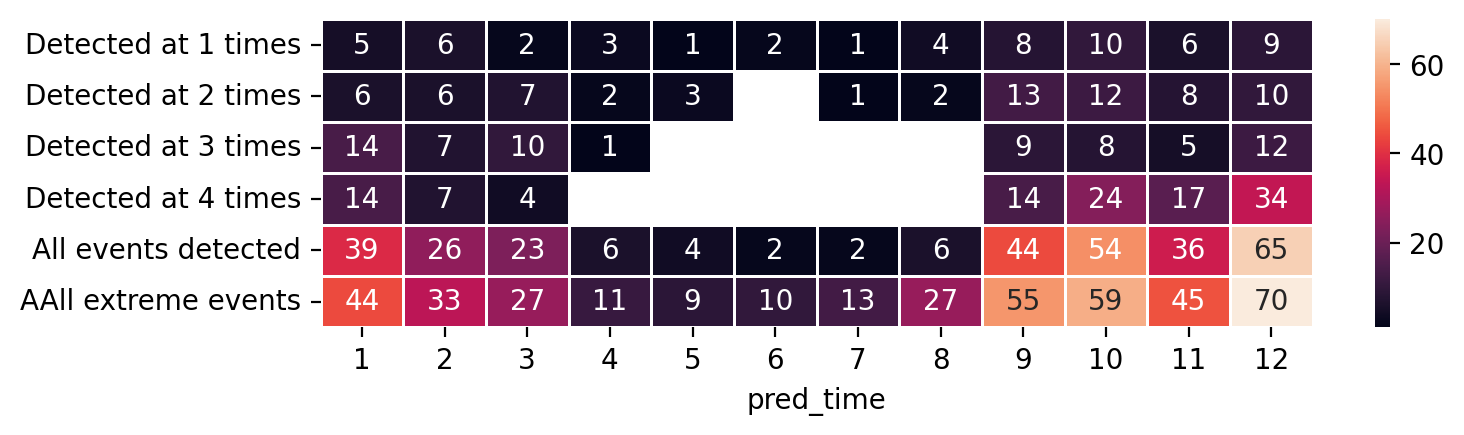

In [85]:
fig,axs = plt.subplots(figsize=(8,2), dpi=200)
df_hm = times.groupby(times.index.month).apply(lambda df:df.value_counts()).unstack()

df_hm.columns = [f'Detected at {k} times' for k in range(1,5)]
df_hm['All events detected'] = df_hm.sum(axis=1).astype(int)

df_hm['AAll extreme events'] = df_.query("targets==2").pred_time.value_counts().index.month.value_counts().sort_index()
sns.heatmap(df_hm.T, square=False, annot=True, linewidth=.5)

<Axes: xlabel='pred_time'>

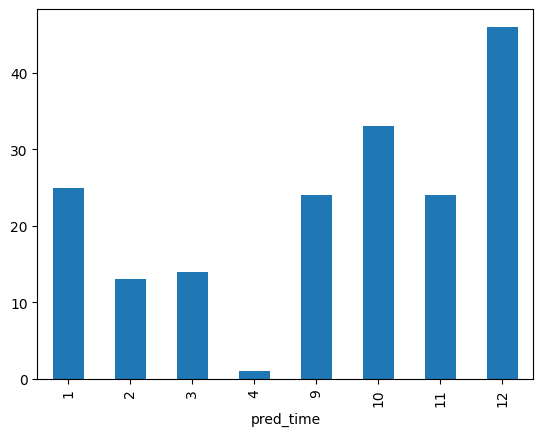

In [26]:
pd.Series(start_times.month).value_counts().sort_index().plot.bar()


In [13]:
from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(events_predicted))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = events_predicted[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=events_predicted[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=events_predicted[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')

  0%|          | 0/114 [00:00<?, ?it/s]

In [14]:
from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs_failed = []
all_multi_sens_failed = []

for k in tqdm(range(len(pred_failed))):
    start = start_times_failed[k].strftime("%Y-%m-%d %H:%M:%S")
    end = pred_failed[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs_failed.append(da_attrs.assign_coords(time=pred_failed[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens_failed.append(sens.assign_coords(time=pred_failed[k]))
ds_attributions_failed = xr.concat(all_multi_attrs_failed, dim='time')
ds_sens_failed = xr.concat(all_multi_sens_failed, dim='time')

  0%|          | 0/572 [00:00<?, ?it/s]

In [ ]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker
def clean_map(plot):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        ax.set_extent([-90, 60, 20, 80], crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='--')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(20,81,20))
        
        longitudes = np.linspace(-90, 60, 100)
        latitudes = np.linspace(20,80,100)
        xx = list(longitudes)[::-1]+\
                [longitudes.min() for _ in range(latitudes.size)] + \
                    list(longitudes)+\
                        [longitudes.max() for _ in range(latitudes.size)]
        yy = [latitudes.max() for _ in range(longitudes.size)] \
                + list(latitudes)[::-1]+\
                    [latitudes.min() for _ in range(longitudes.size)]+ \
                        list(latitudes)[::-1]
        verts = np.array([xx, yy]).T
        circle = Path(verts)
        ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    

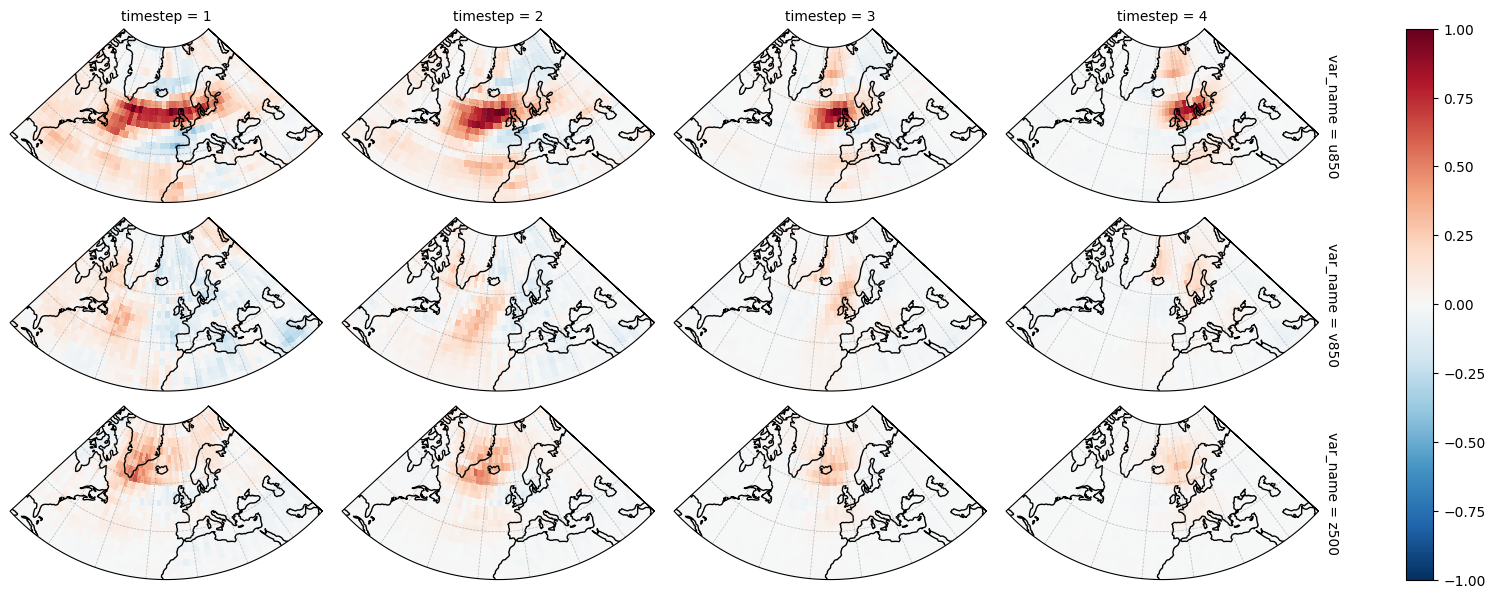

In [56]:

test = ds_attributions.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude', 'var_name'])
projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=projection), aspect=2.1, size=2, transform=ccrs.PlateCarree())

clean_map(plot)

In [ ]:

test = ds_attributions.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude', 'var_name'])
projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=projection), aspect=2.1, size=2, transform=ccrs.PlateCarree())

clean_map(plot)

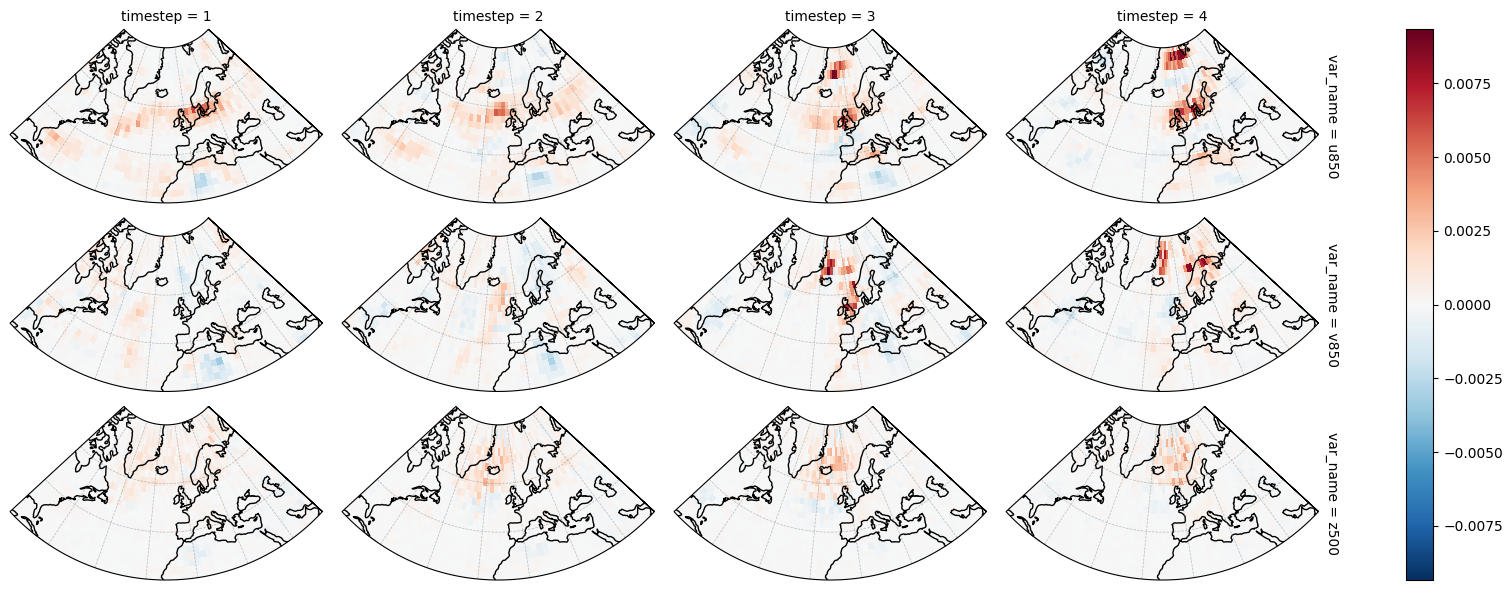

In [66]:

test = ds_attributions.sel(time="2011-11-30")#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
# test = test/test.max(['longitude','latitude', 'var_name'])
# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=projection), aspect=2.1, size=2, transform=ccrs.PlateCarree())

clean_map(plot)

In [65]:
ds_attributions.sum(['longitude','latitude','var_name']).min('timestep').idxmax()

<xarray.DataArray 'time' ()> Size: 8B
array('2011-11-30T00:00:00.000000000', dtype='datetime64[ns]')

In [49]:
plot.axs[0][0].collections

<Axes.ArtistList of 2 collections>

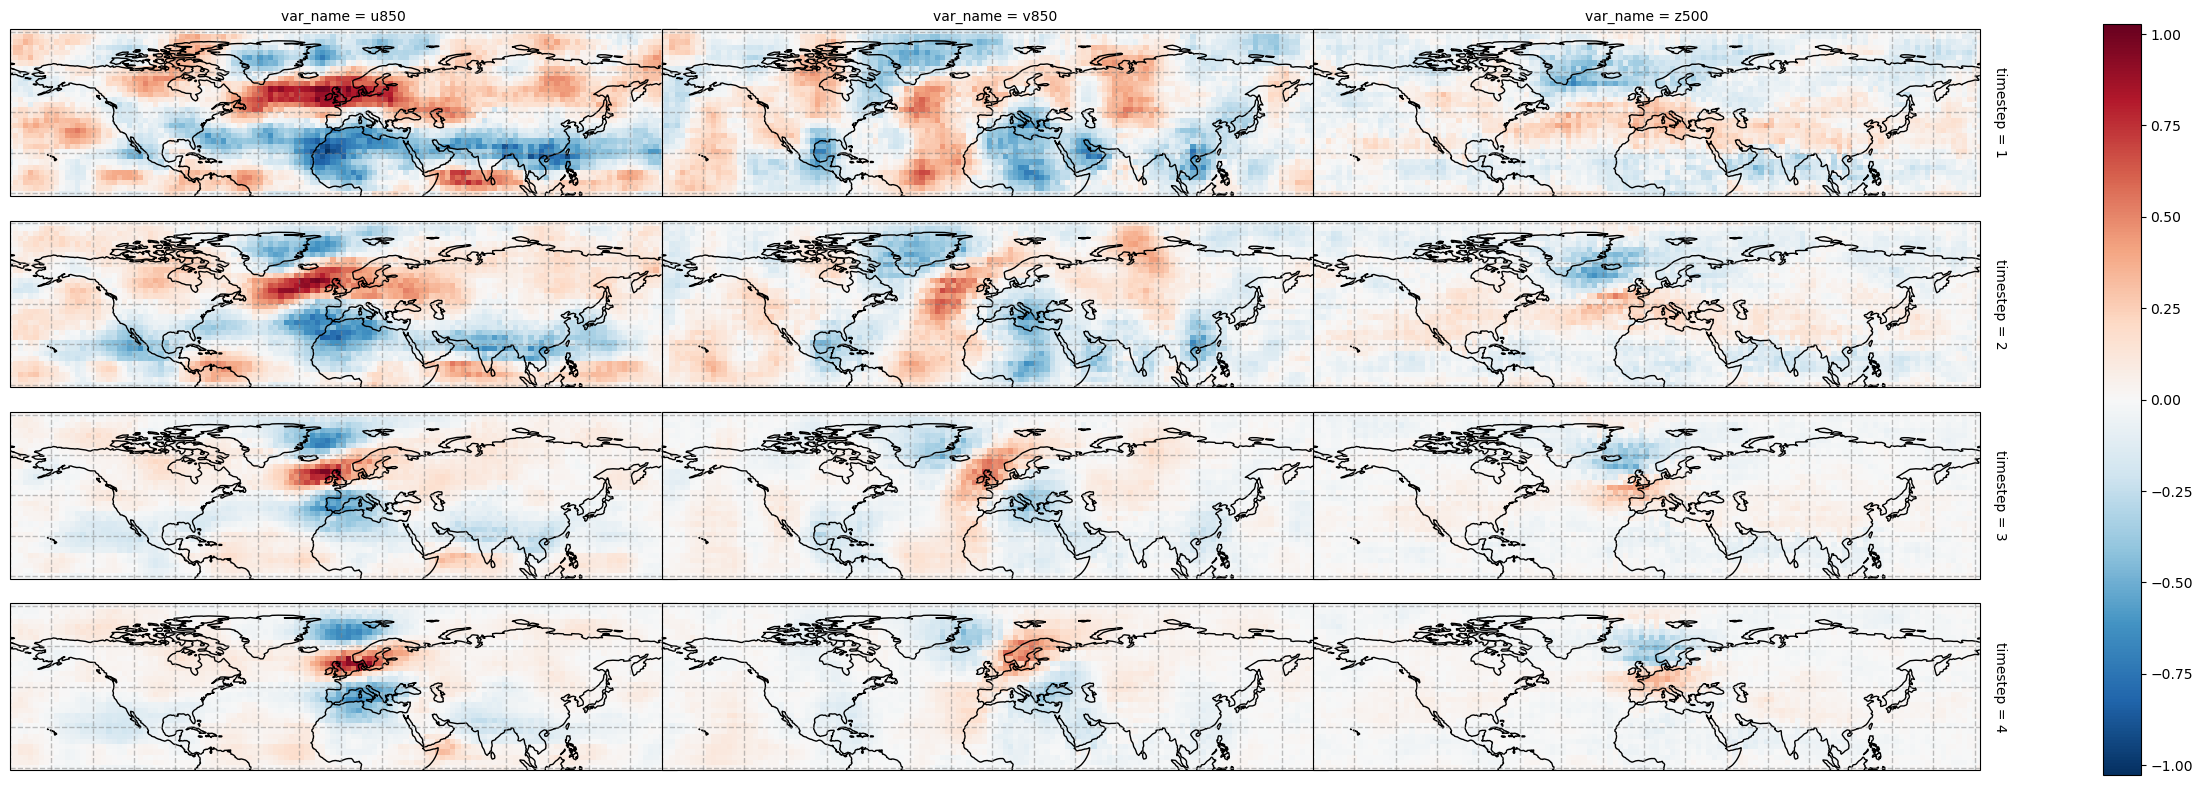

In [21]:
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
test = ds_sens.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude', 'var_name'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17))
    gl.ylocator = mticker.FixedLocator(np.linspace(ds_test.latitude.min(),ds_test.latitude.max(),5))



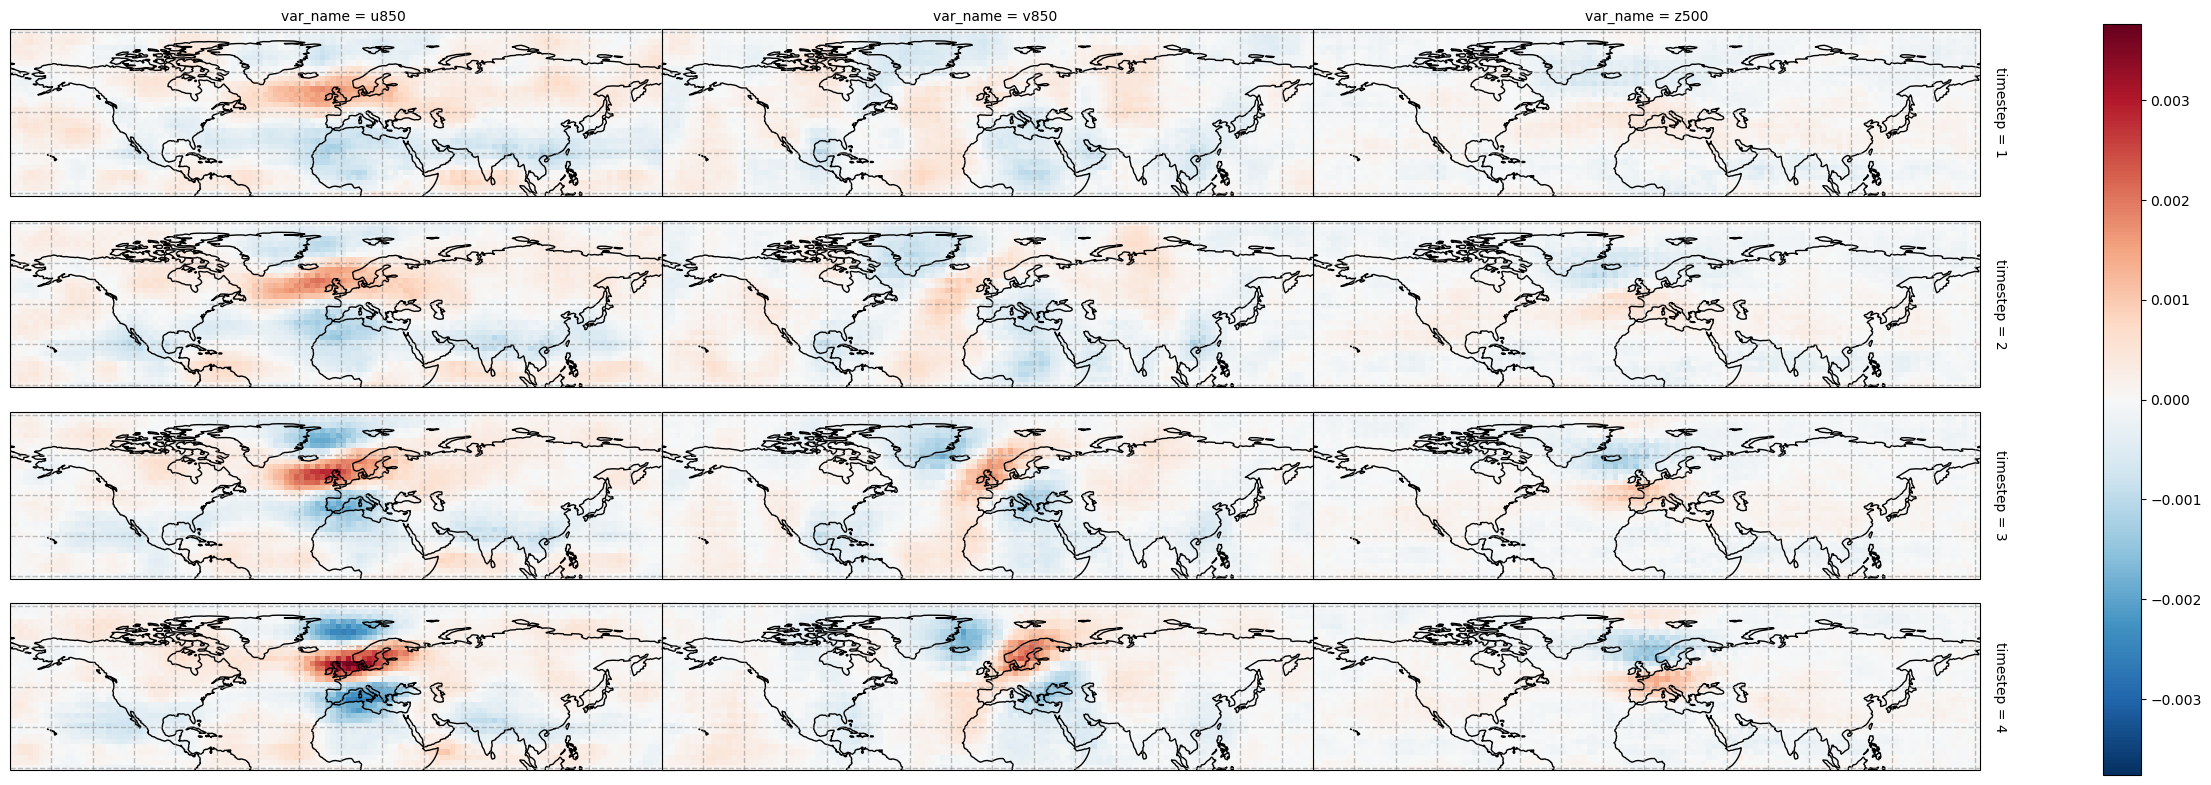

In [18]:
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
test = ds_sens_failed.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
# test = test/test.max(['longitude','latitude', 'var_name'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17))
    gl.ylocator = mticker.FixedLocator(np.linspace(ds_test.latitude.min(),ds_test.latitude.max(),5))



In [ ]:
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
test = ds_attributions.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17))
    gl.ylocator = mticker.FixedLocator(np.linspace(ds_test.latitude.min(),ds_test.latitude.max(),5))



In [ ]:
import cartopy.crs as ccrs
test = np.abs(ds_attributions).mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')

    # ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

In [ ]:
import cartopy.crs as ccrs
test = np.abs(ds_attributions).mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()

    # ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

In [ ]:
import cartopy.crs as ccrs
test = ds_attributions.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    # ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

In [ ]:
import cartopy.crs as ccrs
test = ds_attributions.mean('time')#isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

In [ ]:
import cartopy.crs as ccrs
test = ds_attributions.mean('time')#isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

In [ ]:
test = (np.abs(ds_attributions)).coarsen(longitude=8, latitude=8).mean().mean('time')
test = test/test.std(['longitude','latitude'])
test.plot(col='timestep', row='var_name')

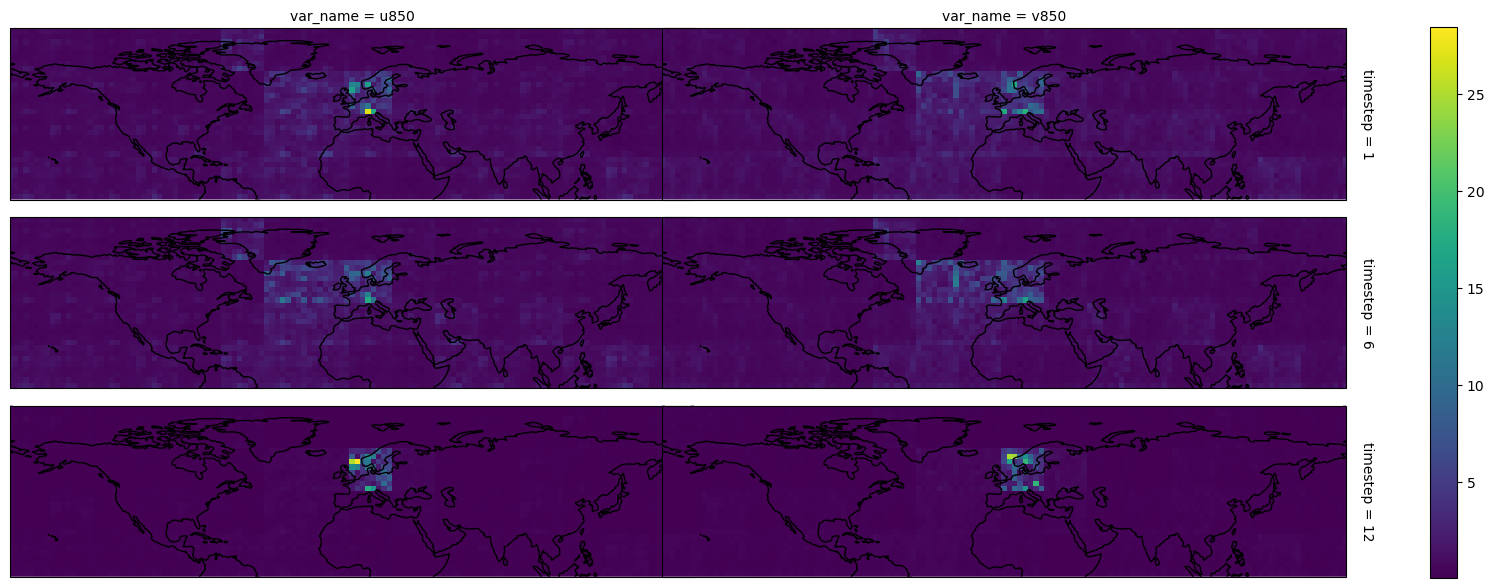

In [ ]:
import cartopy.crs as ccrs
test = np.abs(ds_attributions).mean('time')#isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test = test/test.std(['longitude','latitude'])

# test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.isel(timestep=[0,5,11]).plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    # ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

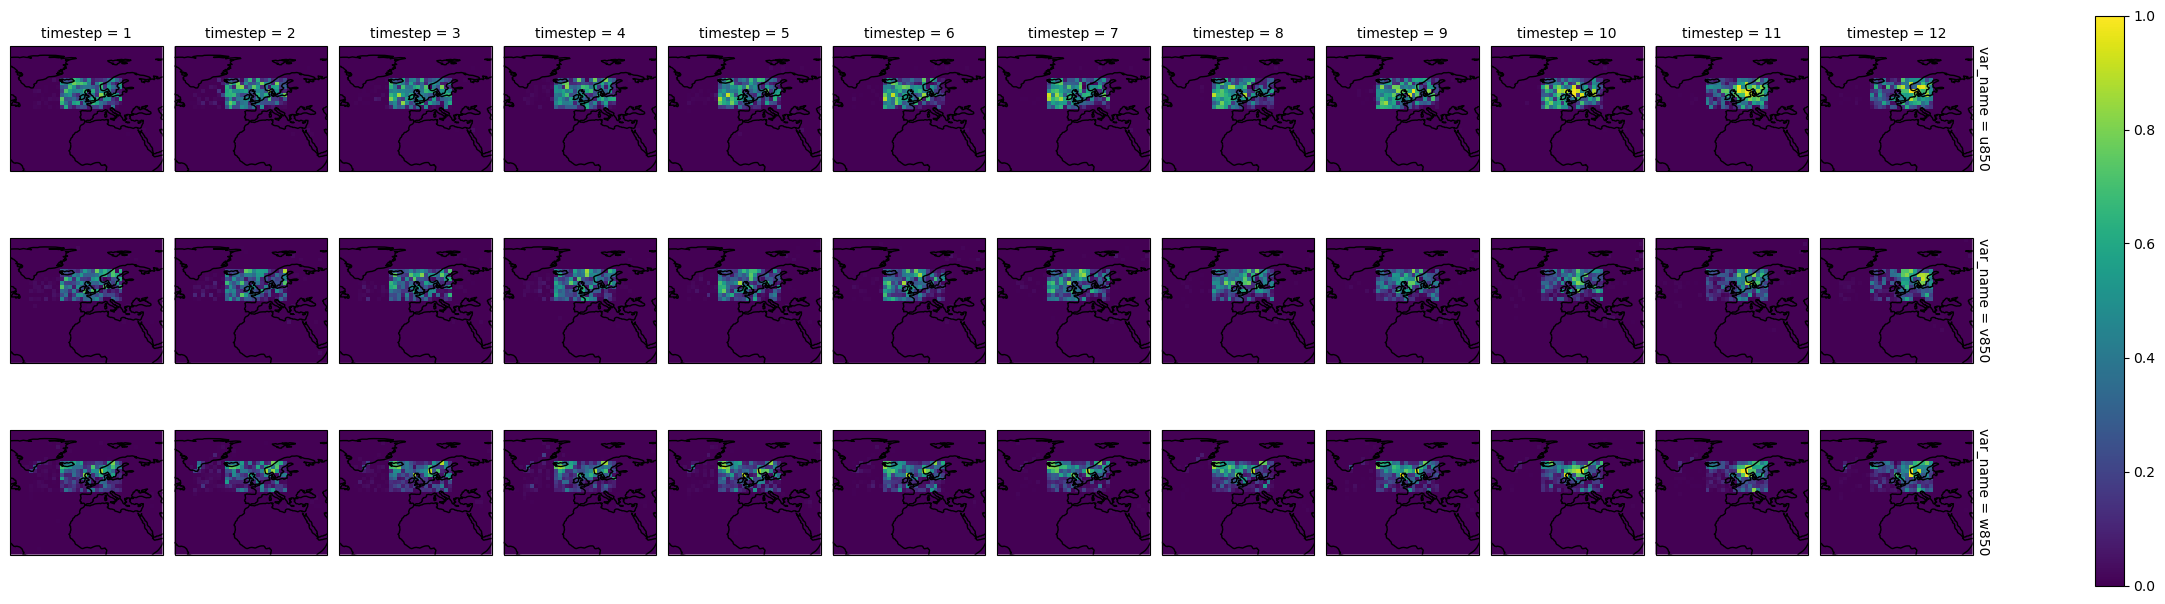

In [26]:
import cartopy.crs as ccrs
# test = ds_attributions.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
# test = np.abs(test.stack(space=['var_name','latitude','longitude'])).rank(pct=True, dim='space').unstack()
# test = test/test.max(['longitude','latitude'])
test = np.abs(ds_attributions.stack(space=['var_name','latitude','longitude'])).rank(pct=True, dim='space').unstack()

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = ((test>.99).sum('time')/test.time.size).plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2, transform=ccrs.PlateCarree(),  extend='neither')
for ax in plot.axs.flatten():
    ax.coastlines()
    ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

<xarray.DataArray (timestep: 12, var_name: 5, latitude: 32, longitude: 128)> Size: 2MB
array([[[[0.        , 0.        , 0.00492611, ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.00246305,
          0.00492611, 0.        ],
         ...,
         [0.        , 0.        , 0.00246305, ..., 0.00738916,
          0.0270936 , 0.        ],
         [0.00246305, 0.        , 0.00738916, ..., 0.04679803,
          0.01477833, 0.00246305],
         [0.        , 0.        , 0.        , ..., 0.02216749,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
...
         [0.        , 0.        , 0.00492611, ..., 0.        ,
          0.00246305, 0.        ],
         [0.01724138, 0.00246305, 0.        , ..., 0.00985222,
          0.        , 0.        ],
         [0.        , 0.00246305, 0.        , ..., 0.02955665,
          0.00246305, 0.        ]],

        [[0.        , 0.        , 0.01231527, ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.00738916, 0.00246305, ..., 0.00492611,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]]])
Coordinates:
  * var_name   (var_name) object 40B 'u850' 'v850' 'w850' 'z500' 'tcwv'
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * timestep   (timestep) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

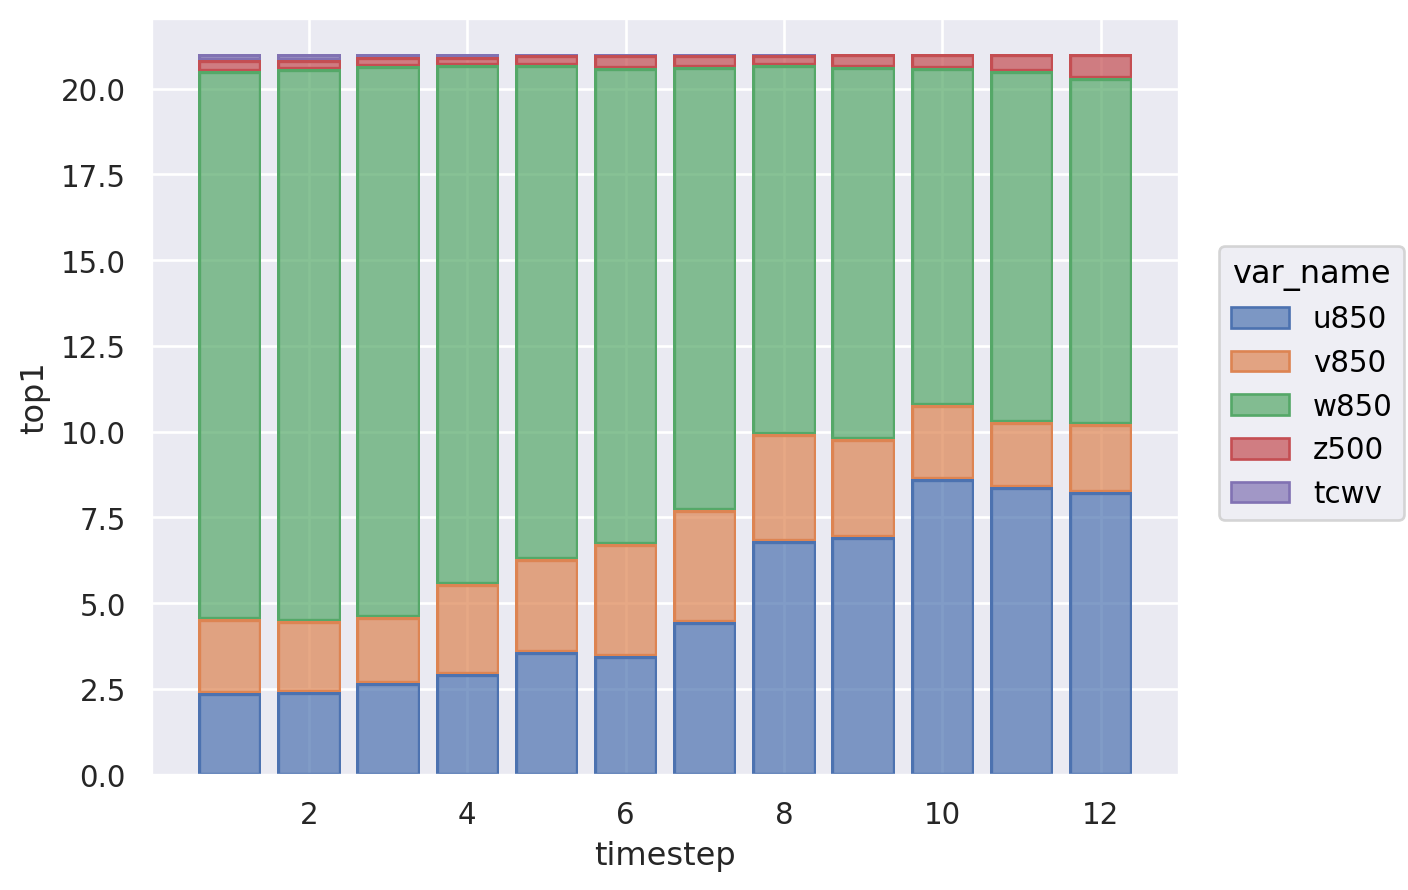

In [98]:
df_= (test>.999).sum(['longitude','latitude']).rename('top1').to_series().reset_index()
# sns.catplot(df_, x='timestep', y='top1', hue='var_name', stacked=True, kind='bar')
import seaborn.objects as so 

(so.Plot(df_,  x='timestep', y='top1', color='var_name', )
    .add(so.Bar(), so.Agg(),so.Stack(), )
 )

/tmp/ipykernel_188062/2010766226.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_ = X.groupby('label').mean().stack().stack().reset_index()


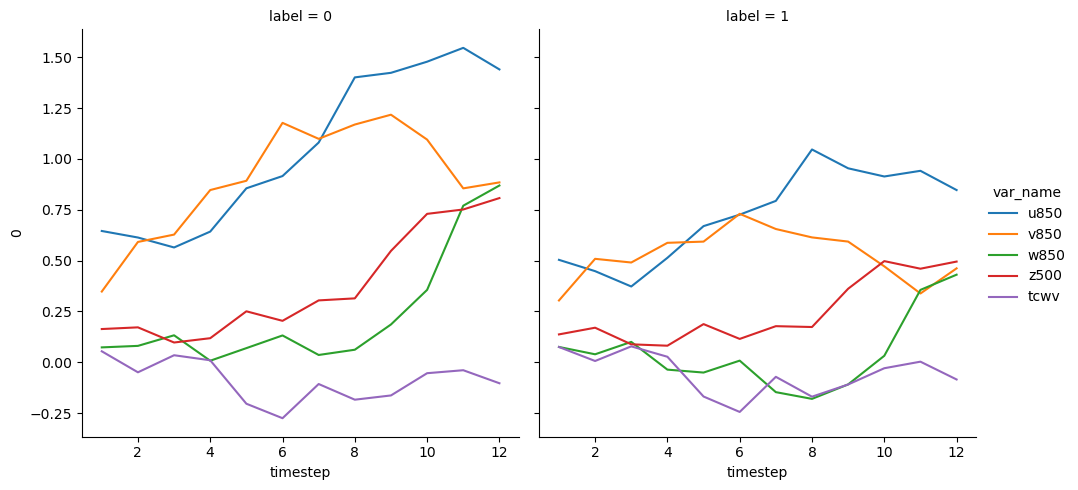

In [59]:
df_ = X.groupby('label').mean().stack().stack().reset_index()
sns.relplot(df_, x='timestep',hue='var_name', y=0,  col='label', kind='line')

In [39]:

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
X = df_.to_series().unstack('time').T
kmeans.fit(X)

X['label'] =kmeans.labels_

<Axes: xlabel='recall', ylabel='prec'>

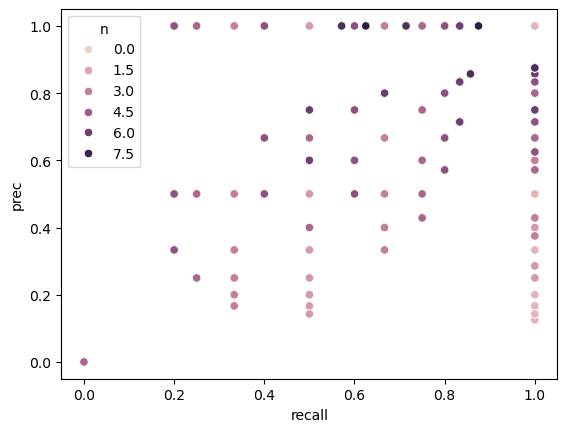

In [11]:
# Is there an event in the next 3 days?
# pred.sum('timestep').plot.hist()
# targets.sum('timestep').plot.hist(bins=np.arange(0,11))
# .plot.hist(bins=np.arange(0,11))
TP = ((pred==targets) & (pred==1)).sum('timestep')
prec = TP/(pred==1).sum('timestep')
recall = TP/(targets==1).sum('timestep')
f1 = 2*prec*recall/(prec+recall) 
df_ = pd.DataFrame(dict(prec=prec.to_series(), recall=recall.to_series(), n = targets.sum('timestep').to_series(), f1 =f1))
sns.scatterplot(df_, x='recall', y='prec', hue='n')

<xarray.DataArray ()> Size: 8B
array(0.52422827)
Coordinates:
    mask_id   int64 8B 14
    quantile  float64 8B 0.9

In [46]:
ds_ = xr.Dataset(dict(pred=pred, targets=targets))
df_ = ds_.to_dataframe().reset_index()
df_ = df_.query("pred==targets & targets==1").reset_index()
df_

,index,time,timestep,mask_id,quantile,pred,targets
0,167,2007-01-26 12:00:00,7,14,0.9,1.0,1.0
1,183,2007-01-27 00:00:00,7,14,0.9,1.0,1.0
2,190,2007-01-27 06:00:00,6,14,0.9,1.0,1.0
3,195,2007-01-27 12:00:00,3,14,0.9,1.0,1.0
4,197,2007-01-27 12:00:00,5,14,0.9,1.0,1.0
...,...,...,...,...,...,...,...
4767,39633,2020-12-27 00:00:00,1,14,0.9,1.0,1.0
4768,39640,2020-12-27 06:00:00,0,14,0.9,1.0,1.0
4769,40066,2021-01-09 12:00:00,2,14,0.9,1.0,1.0
4770,40073,2021-01-09 18:00:00,1,14,0.9,1.0,1.0


In [49]:
ds_ = xr.Dataset(dict(pred=pred, targets=targets))
df_ = ds_.to_dataframe().reset_index()
df_ = df_.query("pred==targets & targets==1").reset_index()
df_['rain_time'] = df_.time + pd.Series([pd.Timedelta(f'{k*6}h') for k in df_.timestep])
df_out = xr.open_dataset(wandb_logger.experiment.config['file_name_data_out']).tp.to_series()
steps = wandb_logger.experiment.config['num_timesteps_predicted']

df_count = df_.groupby(df_.rain_time).time.count()
events_predicted = df_count.loc[df_count==steps].index
start_times = events_predicted - pd.to_timedelta(6*steps-1,'h')


In [52]:
events_predicted

DatetimeIndex(['2007-01-30 18:00:00', '2007-01-31 00:00:00',
               '2007-01-31 06:00:00', '2007-02-02 06:00:00',
               '2007-02-02 12:00:00', '2007-12-05 06:00:00',
               '2007-12-05 12:00:00', '2007-12-05 18:00:00',
               '2007-12-06 00:00:00', '2007-12-06 06:00:00',
               ...
               '2020-02-21 18:00:00', '2020-02-22 00:00:00',
               '2020-02-22 06:00:00', '2020-02-22 12:00:00',
               '2020-02-22 18:00:00', '2020-02-23 00:00:00',
               '2020-12-19 06:00:00', '2020-12-26 06:00:00',
               '2020-12-27 00:00:00', '2020-12-27 06:00:00'],
              dtype='datetime64[ns]', name='rain_time', length=479, freq=None)

In [13]:
df_count.value_counts().sort_index(ascending=False).cumsum()

time
3    515
2    586
1    627
Name: count, dtype: int64

<Axes: xlabel='time'>

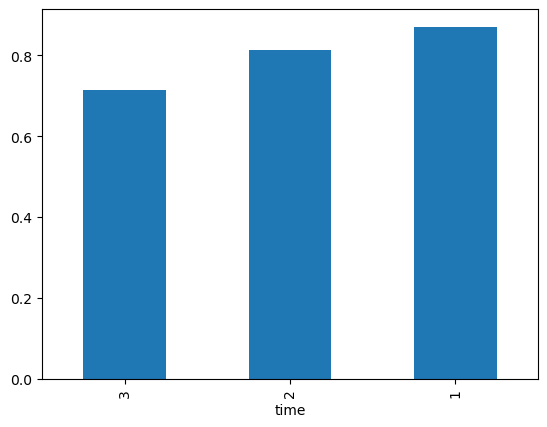

In [14]:
# df_.groupby(df_.timestep).time.count().plot.bar()
(df_count.value_counts().sort_index(ascending=False).cumsum()/720).plot.bar()

In [15]:
from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)

all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(events_predicted))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = events_predicted[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[steps-k-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=events_predicted[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=events_predicted[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')

  0%|          | 0/515 [00:00<?, ?it/s]

In [16]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

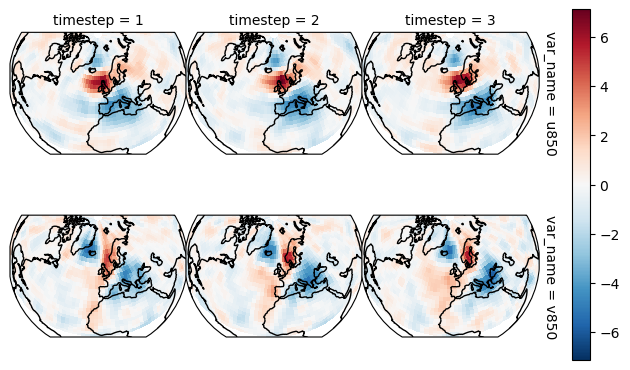

In [20]:
import cartopy.crs as ccrs
test = ds_sens.rolling(longitude=3,latitude=3,center=True).mean().mean('time')#sel(time="2014-12-10 00:00:00")
test = test/test.std(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.Orthographic(-10,60)), aspect=1, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    ax.set_extent((-90,90, 0,90), crs=ccrs.PlateCarree())

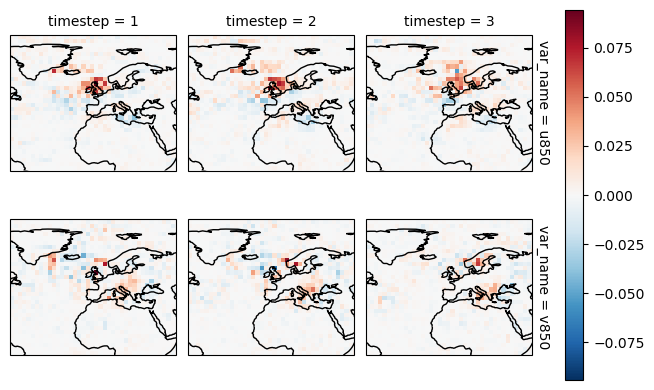

In [ ]:
import cartopy.crs as ccrs
test = ds_attributions.mean('time')#isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
# test = test/test.max(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2, transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()
    ax.set_extent((-60,50, 0,90), crs=ccrs.PlateCarree())

In [32]:
test = np.abs(ds_attributions.sum('var_name'))

def gini_index_array(values):
    """
    Fast Gini index calculation for a 1D numpy array.
    """
    values = np.abs(values.flatten())
    n = len(values)
    
    if np.sum(values) == 0:
        return 0.0
    

    sorted_vals = np.sort(values)
    cumulative = np.cumsum(sorted_vals)
    gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    
    return gini

def compute_gini_per_time(attr_map):
    """
    Compute Gini index for each time step in an xarray.DataArray.
    
    Parameters:
    attr_map: xarray.DataArray with dimensions (time, lat, lon)

    Returns:
    gini_per_time: xarray.DataArray with dimension (time)
    """
    # Apply function along 'time' dimension
    gini_values = xr.apply_ufunc(
        gini_index_array,
        attr_map,
        input_core_dims=[["latitude", "longitude"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    
    return gini_values


gini = compute_gini_per_time(test)

In [108]:
from xarrayutils import xr_linregress

In [123]:
gini.idxmax('time')

<xarray.DataArray 'time' (timestep: 12)> Size: 96B
array(['2015-01-12T06:00:00.000000000', '2015-01-12T00:00:00.000000000',
       '2015-01-12T00:00:00.000000000', '2015-01-11T06:00:00.000000000',
       '2015-01-11T06:00:00.000000000', '2015-01-11T00:00:00.000000000',
       '2015-01-14T00:00:00.000000000', '2015-01-14T00:00:00.000000000',
       '2015-01-14T00:00:00.000000000', '2015-01-14T00:00:00.000000000',
       '2015-01-14T00:00:00.000000000', '2015-01-14T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * timestep  (timestep) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

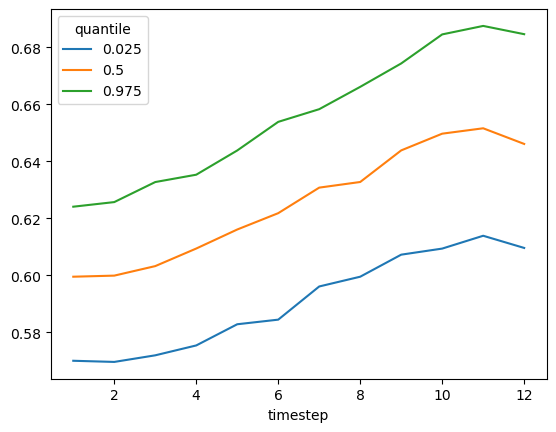

In [33]:
gini.quantile([0.025,0.5,0.975],'time').plot(hue='quantile')

(0.0, 100.0)

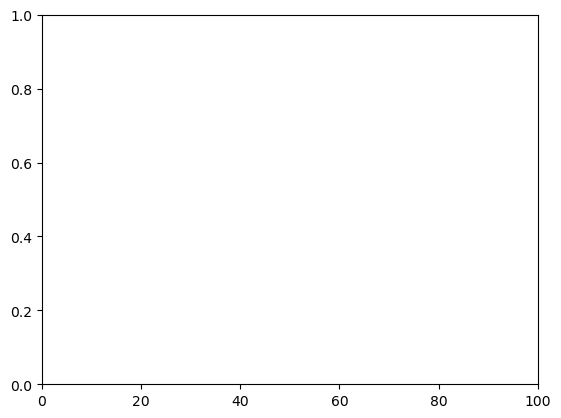

In [85]:
cumprob = sigmoid(test.where(test>0,0).to_series().unstack('timestep').transform(np.sort).iloc[::-1].cumsum())

max_prob = sigmoid(test.where(test>0,0).sum(['longitude','latitude','var_name'])).to_series()
plt.xlim(0,100)

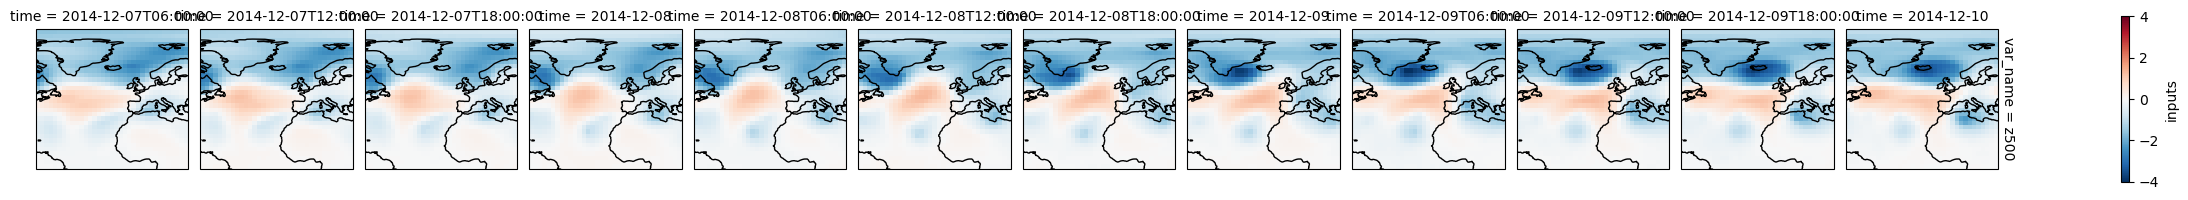

In [ ]:
import cartopy.crs as ccrs
test = ds_test.inputs.sel(time=slice(None,"2014-12-10 00:00:00")).isel(time=slice(-12,None))#mean('time')
# test = test/test.std(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.sel(longitude=slice(-70,30)).plot(col='time', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()

In [38]:
# test = xr.DataArray(np.arange(.01,.1,.01), dims=['thresh'], coords = dict(thresh=np.arange(.01,.1,.01)))
sparsity = (np.abs(ds_attributions)>.001).sum(['longitude','latitude','var_name']) /ds_attributions.count(['longitude','latitude','var_name'])

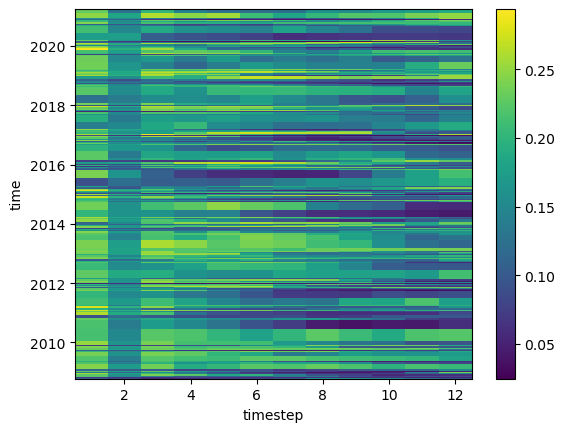

In [40]:
sparsity.plot()

<Axes: xlabel='timestep', ylabel='sparsity'>

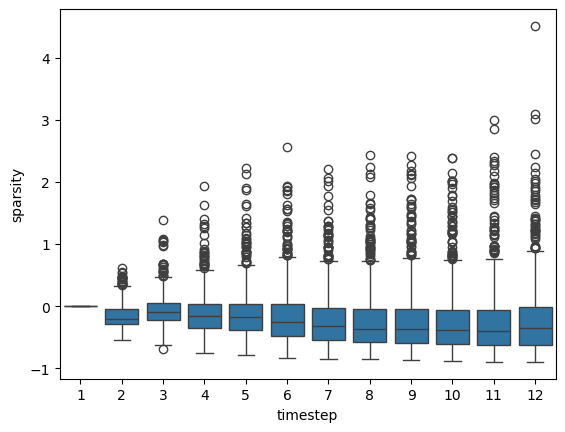

In [43]:
df_ = ((sparsity-sparsity.sel(timestep=1))/(sparsity.sel(timestep=1))).rename('sparsity').to_series().reset_index()
sns.boxplot(df_, x='timestep', y='sparsity')

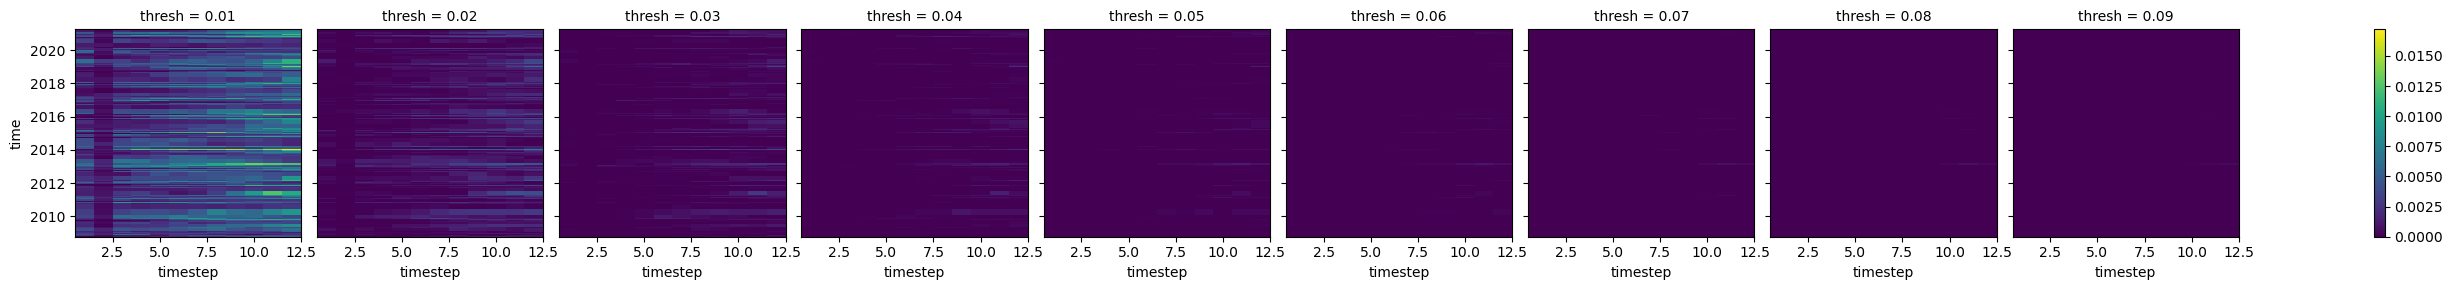

In [18]:
sparsity.plot(col='thresh')

In [143]:
np.abs(ds_attributions)>log_test

ValueError: operands could not be broadcast together with shapes (810,12,4,32,128) (91,) 

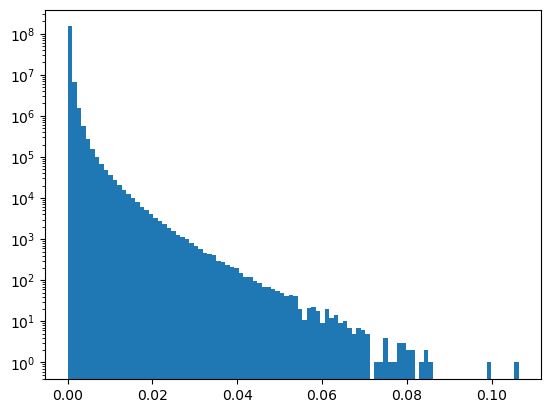

In [140]:
np.abs(ds_attributions).plot.hist(bins=100)
plt.yscale('log')

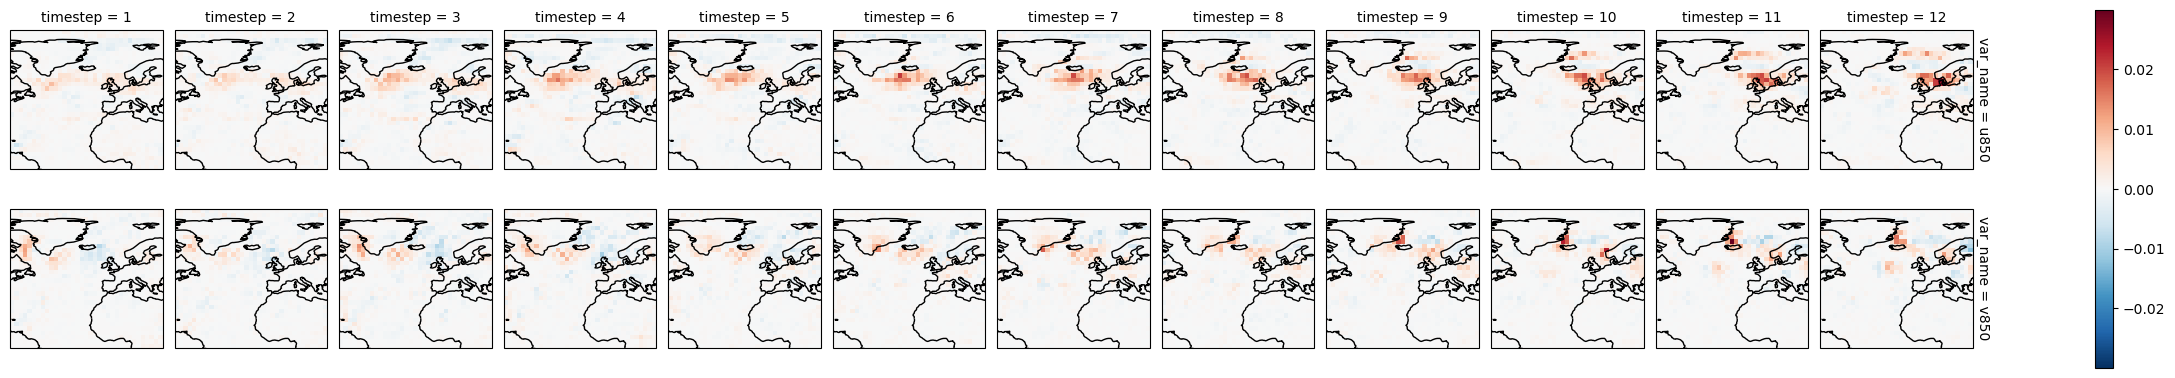

In [79]:
import cartopy.crs as ccrs
test = ds_attributions.isel(time=10)
# test = test/test.std(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.sel(longitude=slice(-70,30)).plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()

In [83]:
ds_test.sel(time=events_predicted)

<xarray.Dataset> Size: 26MB
Dimensions:    (latitude: 32, var_name: 2, longitude: 128, time: 782,
                timestep: 12)
Coordinates:
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * var_name   (var_name) object 16B 'u850' 'v850'
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * time       (time) datetime64[ns] 6kB 2008-10-10T12:00:00 ... 2021-03-31
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    inputs     (time, var_name, latitude, longitude) float32 26MB -0.2925 ......
    targets    (time, timestep) float32 38kB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0

In [ ]:
import cartopy.crs as ccrs
test = ds_test.inputs.sel(time=slice(None,ds_attributions.time[10])).isel(time=slice(-12,None))#mean('time')
# test = test/test.std(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.sel(longitude=slice(-70,30)).plot(col='time', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()

In [ ]:
ranks = np.abs(ds_attributions).stack(space=['var_name','latitude','longitude']).rank('space').unstack()


In [ ]:
d = ds_attributions.longitude.size * ds_attributions.latitude.size * ds_attributions.var_name.size
indices = np.arange(1,d+1)
numerator = np.sum((2 * indices - d - 1) * sorted_attr)

In [72]:
test = np.abs(ds_attributions.sum('var_name'))

def gini_index_array(values):
    """
    Fast Gini index calculation for a 1D numpy array.
    """
    values = np.abs(values.flatten())
    n = len(values)
    
    if np.sum(values) == 0:
        return 0.0
    
    sorted_vals = np.sort(values)
    cumulative = np.cumsum(sorted_vals)
    gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    
    return gini

def compute_gini_per_time(attr_map):
    """
    Compute Gini index for each time step in an xarray.DataArray.
    
    Parameters:
    attr_map: xarray.DataArray with dimensions (time, lat, lon)

    Returns:
    gini_per_time: xarray.DataArray with dimension (time)
    """
    # Apply function along 'time' dimension
    gini_values = xr.apply_ufunc(
        gini_index_array,
        attr_map,
        input_core_dims=[["latitude", "longitude"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    
    return gini_values


gini = compute_gini_per_time(test)

<Axes: xlabel='timestep', ylabel='gini'>

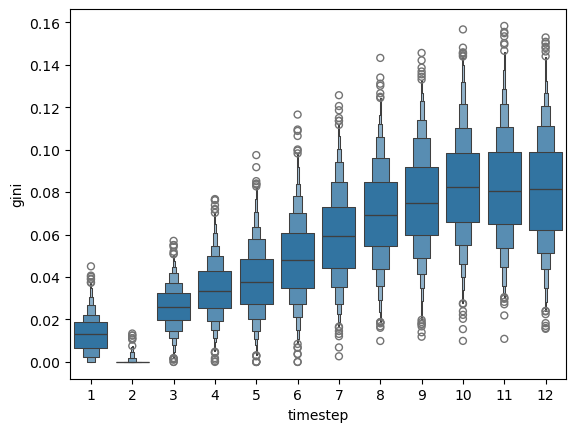

In [75]:
df_ = (gini-gini.min('timestep')).rename('gini').to_series().reset_index()
sns.boxenplot(df_, x='timestep', y='gini')

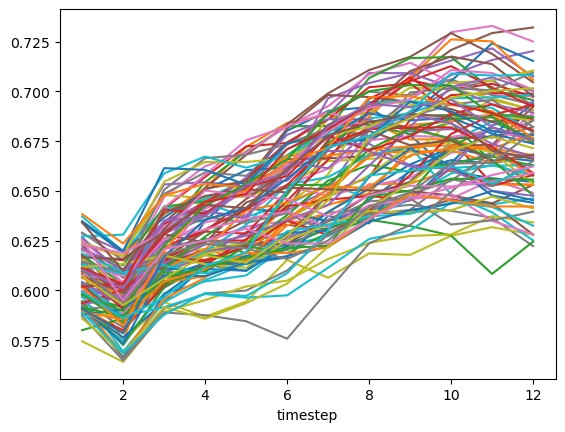

In [74]:
gini.isel(time=range(100)).plot(hue='time', add_legend=False);

(0.0, 10.0)

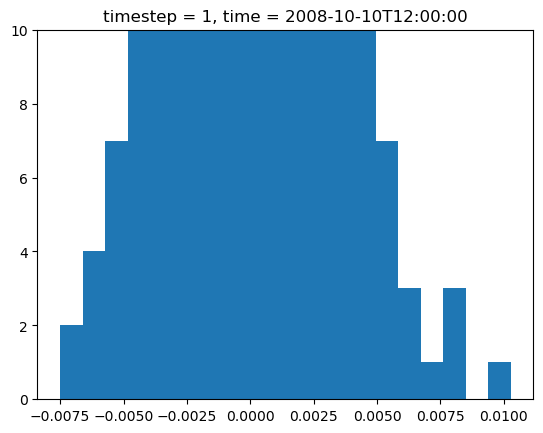

In [111]:
ds_attributions.isel(time=0, timestep=0).plot.hist(bins=20)
plt.ylim(0,10)

In [115]:
import cartopy.crs as ccrs
sample = 50
test = ds_attributions.isel(time=sample)#mean('time')
test = test/test.std(['longitude','latitude'])

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
plot = test.sel(longitude=slice(-70,30)).mean().plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=1, size=2, cmap = 'RdBu_r')
for ax in plot.axs.flatten():
    ax.coastlines()
    ax.plot(lon_attr.isel(time=sample).isel(var_name=1), lat_attr.isel(time=sample).isel(var_name=0), transform=ccrs.PlateCarree())

TypeError: No numeric data to plot.

In [58]:
lat_maps = xr.ones_like(ds_attributions)*ds_attributions.latitude
lon_maps = xr.ones_like(ds_attributions)*ds_attributions.longitude
lat_attr = lat_maps.weighted(pos_sens_significant).mean(['longitude','latitude'])
lon_attr = lon_maps.weighted(pos_sens_significant).mean(['longitude','latitude']) 

In [ ]:
ds_attributions.sum(['var_name']).isel(time=0).plot(col='timestep')

In [ ]:
pos_sens_significant = np.abs(ds_attributions).where(np.abs(ds_attributions)>0.1*np.abs(ds_attributions).max(['longitude','latitude','timestep'])).fillna(0)

pos_sens_significant.isel(time=0, timestep=0, var_name=0).plot()

In [51]:
lon_attr

<xarray.DataArray (time: 810, timestep: 12)> Size: 78kB
array([[ 0.81007913, -0.29110186,  0.3019513 , ...,  0.34325759,
         5.51035062, 10.52364169],
       [ 2.21169749, -2.47955206, -1.93880455, ..., -0.33324591,
         3.93108807,  9.96131388],
       [ 0.33464384, -2.98153853, -3.35256307, ..., -0.58061971,
         4.72505336, 10.95022122],
       ...,
       [-1.11113174, -7.97276917, -4.24818025, ...,  0.33379396,
         3.20352573, 10.48741537],
       [-3.08558444, -6.00576901, -4.41900176, ..., -0.03144998,
         3.5727774 ,  6.52963265],
       [-2.51138903, -5.14233257, -3.0712879 , ...,  0.5936947 ,
         4.12986481,  5.4368618 ]])
Coordinates:
  * timestep  (timestep) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * time      (time) datetime64[ns] 6kB 2008-10-10T12:00:00 ... 2021-03-30T18...
    mask_id   int64 8B 14
    quantile  float64 8B 0.9

In [ ]:
import cartopy.crs as ccrs
plot = ds_attributions.isel(time=0).rolling(longitude=3,latitude=3,center=True).mean().sum('var_name').plot(row='timestep', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()

In [ ]:
pos_sens_significant = ds_sens.where(ds_sens>0.1*ds_sens.max(['longitude','latitude','time'])).fillna(0)


In [ ]:
import cartopy.crs as ccrs
plot = pos_sens_significant.isel(time=0).plot(row='timestep', col='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4)
for ax in plot.axs.flatten():
    ax.coastlines()

In [31]:
lat_maps = xr.ones_like(ds_attributions)*ds_attributions.latitude
lon_maps = xr.ones_like(ds_attributions)*ds_attributions.longitude
lat_attr = lat_maps.weighted(pos_sens_significant).mean(['longitude','latitude','var_name'])
lon_attr = lon_maps.weighted(pos_sens_significant).mean(['longitude','latitude','var_name']) 

NameError: name 'pos_sens_significant' is not defined

In [ ]:
import cartopy.crs as ccrs 

fig, ax = plt.subplots(figsize=(10,5),subplot_kw=dict(projection = ccrs.PlateCarree()))
for k in range(600):
    ax.plot(lon_attr.isel(time=k),lat_attr.isel(time=k), transform=ccrs.PlateCarree(), marker ='o', alpha=.3, color='C3')

ax.set_extent((-60,50,40,80), crs=ccrs.PlateCarree())
ax.coastlines()


In [45]:
from sklearn.decomposition import PCA
X = ds_attributions.fillna(0).stack(space=['latitude','longitude','var_name','timestep']).values
pca = PCA(n_components=10, )
pca.fit(X)

PCA(n_components=10)

In [15]:
X.shape

(343, 98304)

In [16]:
pca.fit_transform(X).shape

(343, 100)

In [22]:
X.shape

(343, 98304)

In [21]:
X_tilda.shape

(343, 98304)

In [90]:
X_tilda = pca.inverse_transform(pca.transform(X))

X_eofs100 = xr.DataArray(X_tilda.reshape(343,32,128,2,steps), dims=['time','latitude','longitude','var_name','timestep'],
             coords=dict(time=ds_attributions.time, latitude=ds_attributions.latitude, longitude=ds_attributions.longitude, timestep=ds_attributions.timestep, var_name=ds_attributions.var_name))

In [91]:
X_eofs100_proba =  (1/(1+np.exp(-X_eofs100.sum(['longitude','latitude','var_name']))))
proba =  (1/(1+np.exp(-ds_attributions.sum(['longitude','latitude','var_name']))))

In [98]:
# proba =
proba

<xarray.DataArray (time: 343, timestep: 12)> Size: 16kB
array([[0.7458956 , 0.8521396 , 0.8787835 , ..., 0.98604554, 0.97988796,
        0.9750895 ],
       [0.8657662 , 0.93524176, 0.94185746, ..., 0.9854214 , 0.9802269 ,
        0.97197986],
       [0.8857529 , 0.9015525 , 0.9275401 , ..., 0.9157905 , 0.9263835 ,
        0.95593894],
       ...,
       [0.7594866 , 0.8128651 , 0.8197198 , ..., 0.933177  , 0.92486775,
        0.9554113 ],
       [0.7506828 , 0.7897798 , 0.78543335, ..., 0.8986903 , 0.9059323 ,
        0.95521265],
       [0.7390574 , 0.75503355, 0.7692458 , ..., 0.935369  , 0.89658153,
        0.89276195]], dtype=float32)
Coordinates:
  * timestep  (timestep) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * time      (time) datetime64[ns] 3kB 2008-10-11T06:00:00 ... 2020-12-20T18...

In [ ]:
import cartopy.crs as ccrs
plot = X_eofs100.sel(longitude=slice(-50,30), latitude=slice(20,None)).max('case').plot(col='timestep', row='var_name', subplot_kws=dict(projection=ccrs.PlateCarree()))
for ax in plot.axs.flatten():
    ax.coastlines()
        

ValueError: Only 1d and 2d plots are supported for facets in xarray. See the package `Seaborn` for more options.

In [ ]:
ds_attributions.isel(time=101).plot(col='timestep', row='var_name', vmax = .1)

<Axes: >

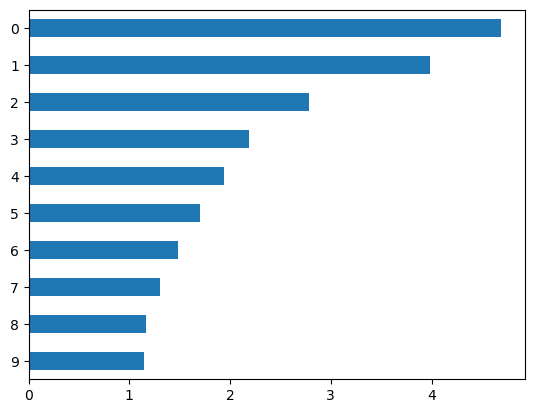

In [50]:
(pd.Series(pca.explained_variance_ratio_).iloc[:10][::-1]*100).plot.barh()

In [46]:
eofs = xr.DataArray(pca.components_.reshape(10,32,128,2,steps), dims=['feature','latitude','longitude','var_name','timestep'],
             coords=dict(feature=np.arange(10), latitude=ds_attributions.latitude, longitude=ds_attributions.longitude, timestep=ds_attributions.timestep, var_name=ds_attributions.var_name))

In [ ]:
for k in range(4):
    plot = eofs.isel(feature=k).sel(longitude=slice(-30,20), latitude=slice(40,None)).plot(col='timestep',row='var_name', subplot_kws=dict(projection=ccrs.PlateCarree()))
    for ax in plot.axs.flatten():
        ax.coastlines()



In [135]:
import hvplot.xarray

In [168]:
eofs.isel(feature=0,var_name=0).hvplot(
    groupby="timestep",  # adds a widget for time
    clim=(-.1, .1),  # sets colormap limits
    cmap='RdBu_r',
    widget_type="scrubber",
    widget_location="bottom",
    roz='var_name',
    geo=True, coastline=True
) + eofs.isel(feature=0, var_name=1).hvplot(
    groupby="timestep",  # adds a widget for time
    clim=(-.1, .1),  # sets colormap limits
    cmap='RdBu_r',
    widget_type="scrubber",
    widget_location="bottom",
    geo=True, coastline=True
) 

BokehModel(combine_events=True, render_bundle={'docs_json': {'75219585-195f-40a3-8905-052c53cfe45f': {'version…

Column
    [0] HoloViews(DynamicMap, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber')
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=7, width=550)
    [2] HoloViews(DynamicMap, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber')
    [3] WidgetBox(align=('center', 'end'))
        [0] Player(end=7, width=550)

In [ ]:
eofs.isel(feature=1,var_name=0).hvplot(
    groupby="timestep",  # adds a widget for time
    clim=(-.1, .1),  # sets colormap limits
    cmap='RdBu_r',
    widget_type="scrubber",
    widget_location="bottom",
    roz='var_name',
    geo=True, coastline=True
) + eofs.isel(feature=1, var_name=1).hvplot(
    groupby="timestep",  # adds a widget for time
    clim=(-.1, .1),  # sets colormap limits
    cmap='RdBu_r',
    widget_type="scrubber",
    widget_location="bottom",
    geo=True, coastline=True
) 

In [ ]:
eofs.isel(feature=2,var_name=0).hvplot(
    groupby="timestep",  # adds a widget for time
    clim=(-.1, .1),  # sets colormap limits
    cmap='RdBu_r',
    widget_type="scrubber",
    widget_location="bottom",
    roz='var_name',
    geo=True, coastline=True
) + eofs.isel(feature=2, var_name=1).hvplot(
    groupby="timestep",  # adds a widget for time
    clim=(-.1, .1),  # sets colormap limits
    cmap='RdBu_r',
    widget_type="scrubber",
    widget_location="bottom",
    geo=True, coastline=True
) 

In [ ]:
import cartopy.crs as ccrs
plot = eofs.isel(feature=2).plot(row='timestep', col='var_name',subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=4, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()
    

In [81]:
X.shape

(632, 8192)

<Axes: >

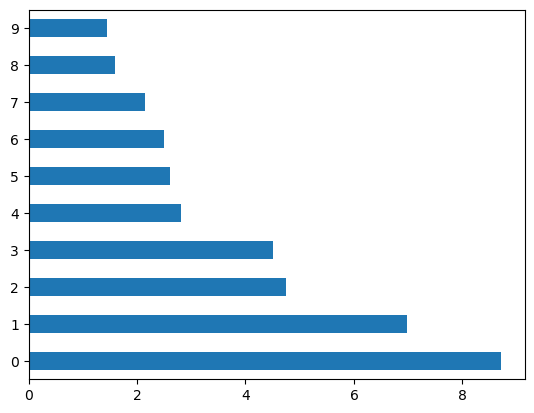

In [94]:
test = ((xr.ones_like(ds_attributions)*ds_attributions.latitude)*ds_attributions).sum(['longitude','latitude'])/ds_attributions.sum(['longitude','latitude'])
test.isel(time=0)

<xarray.DataArray (timestep: 8, var_name: 2)> Size: 128B
array([[185.27862553,  55.27451449],
       [ 23.25952205,  56.58822707],
       [ 48.27881151,  59.81984175],
       [ 62.54856548,  61.93609318],
       [ 61.67486343,  66.26647314],
       [ 59.706744  ,  61.20880921],
       [ 55.74004888,  65.83450754],
       [ 55.20997223, 116.13788527]])
Coordinates:
  * timestep  (timestep) int64 64B 1 2 3 4 5 6 7 8
  * var_name  (var_name) object 16B 'u850' 'v850'
    time      datetime64[ns] 8B 2008-10-10T12:00:00

In [55]:
print(start_times[0].strftime("%Y-%m-%H %H:%M:%S") )
print(events_predicted[0].strftime("%Y-%m-%H %H:%M:%S"))

2008-10-18 18:00:00
2008-10-12 12:00:00


In [ ]:
df_out.loc[events_predicted].sort_values()

# time = "2018-09-26 06:00:00"

rain_time
2011-10-30 12:00:00     4.524539
2012-09-17 18:00:00     4.525185
2008-10-21 12:00:00     4.539183
2016-12-22 00:00:00     4.539621
2016-02-20 12:00:00     4.542598
                         ...    
2020-01-11 12:00:00    17.461617
2019-09-14 18:00:00    17.801964
2014-10-28 12:00:00    18.042212
2008-10-25 18:00:00    18.077085
2018-09-26 06:00:00    23.280489
Name: tp, Length: 632, dtype: float32

In [11]:
tensor_in = torch.Tensor(ds_test.sel(time=slice("2018-09-24 12:00:00","2018-09-26 06:00:00")).inputs.values)
tensor_out = torch.Tensor(ds_test.sel(time=slice("2018-09-24 12:00:00","2018-09-26 06:00:00")).targets.values)

In [12]:
from torch.utils.data import TensorDataset
dataset  = TensorDataset(tensor_in, tensor_out)

In [13]:
from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[7,6,5,4,3,2,1,0]) 
da_attrs = xr.DataArray(attrs, dims = ['time','var_name','latitude','longitude'], coords=ds_test.sel(time=slice("2018-09-24 12:00:00","2018-09-26 06:00:00")).coords)
# all_attrs = []
# for k in tqdm(range(8)):
#     attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[0,1,2,3,4])
#     all_attrs.append(attrs)

In [ ]:
da_attrs.plot(col='time', row='var_name', vmax=.03)

In [ ]:
(da_attrs/ds_test).sel(time=slice("2018-09-24 12:00:00","2018-09-26 06:00:00")).inputs.plot(col='time', row='var_name')

In [21]:
model(tensor_in))

SyntaxError: unmatched ')' (2468857690.py, line 1)

In [23]:
with torch.no_grad():
    print(model(tensor_in).shape)

torch.Size([16, 8])


In [28]:
df = ((pred == targets) & (pred==1))
df['pred'] = pred 
df['targets'] = targets 

df_ = df.where(df).to_series().dropna().reset_index()
# df_['rain_time'] = df_.time + pd.Series([pd.Timedelta(f'{k*6}H') for k in df_.timestep])

In [29]:
df_

,time,timestep,0
0,2008-10-08 06:00:00,1,1.0
1,2008-10-08 12:00:00,0,1.0
2,2008-10-08 18:00:00,7,1.0
3,2008-10-09 00:00:00,6,1.0
4,2008-10-09 00:00:00,7,1.0
...,...,...,...
9298,2021-09-23 06:00:00,1,1.0
9299,2021-09-23 12:00:00,0,1.0
9300,2021-09-23 18:00:00,3,1.0
9301,2021-09-24 00:00:00,2,1.0


In [23]:
df_count = df_.groupby(df_.rain_time).time.count()
events_predicted = df_count.loc[df_count==8].index

df_.loc[df_.rain_time.isin(events_predicted)]

,time,timestep,0,rain_time
2,2008-10-08 18:00:00,7,1.0,2008-10-10 12:00:00
3,2008-10-09 00:00:00,6,1.0,2008-10-10 12:00:00
4,2008-10-09 00:00:00,7,1.0,2008-10-10 18:00:00
5,2008-10-09 06:00:00,5,1.0,2008-10-10 12:00:00
6,2008-10-09 06:00:00,6,1.0,2008-10-10 18:00:00
...,...,...,...,...
9295,2021-09-23 00:00:00,1,1.0,2021-09-23 06:00:00
9296,2021-09-23 00:00:00,2,1.0,2021-09-23 12:00:00
9297,2021-09-23 06:00:00,0,1.0,2021-09-23 06:00:00
9298,2021-09-23 06:00:00,1,1.0,2021-09-23 12:00:00


In [11]:
TP = ((pred == targets) & (pred==1)).sum(['time'])
recall = TP / (targets==1).sum(['time'])
prec = TP / (pred==1).sum(['time'])
F1 = 2*(recall*prec)/(recall+prec)

<Axes: xlabel='pred_thresh', ylabel='timestep'>

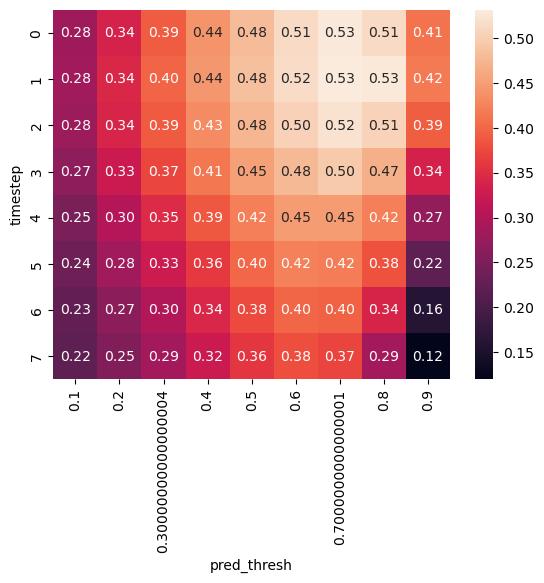

In [10]:
sns.heatmap(F1.to_series().unstack(), annot=True, fmt='.02f')

<Axes: xlabel='pred_thresh', ylabel='timestep'>

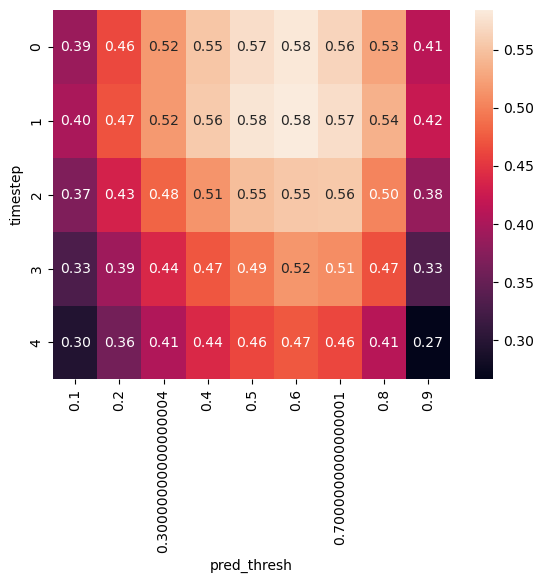

In [10]:
sns.heatmap(F1.to_series().unstack(), annot=True, fmt='.02f')

<Axes: xlabel='pred_thresh', ylabel='timestep'>

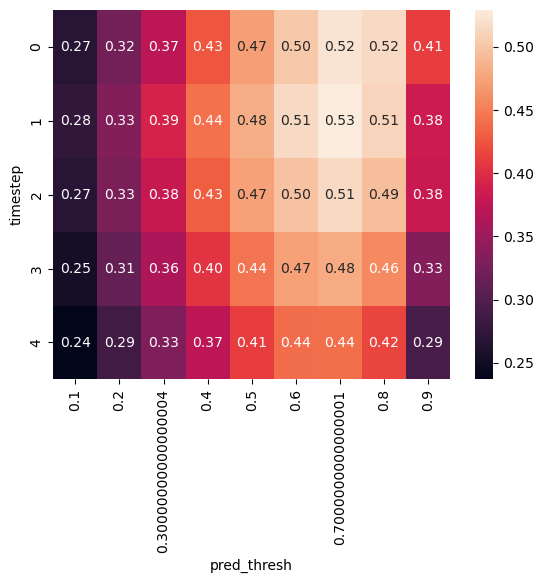

In [15]:
sns.heatmap(F1.to_series().unstack(), annot=True, fmt='.02f')

<Axes: xlabel='pred_thresh', ylabel='timestep'>

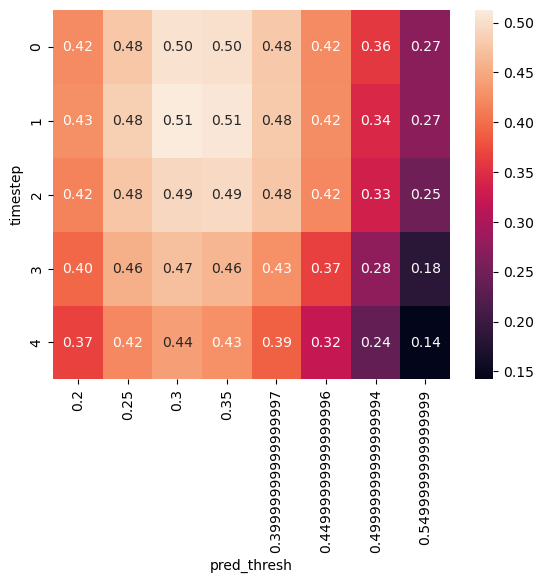

In [45]:
sns.heatmap(F1.to_series().unstack(), annot=True, fmt='.02f')

In [20]:
pred.sum('time')
targets.sum('time')

<xarray.DataArray (timestep: 5)> Size: 20B
array([2111., 2112., 2112., 2112., 2112.], dtype=float32)
Coordinates:
    mask_id   int64 8B 14
    quantile  float64 8B 0.9
Dimensions without coordinates: timestep

In [ ]:
# 